In [ ]:
# cell 0
# run
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# cell 1
import os

DATASET_PATH = "/content/drive/MyDrive/BraTS2023_extracted"

num_patients = sum(
    1 for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
)

print("Number of patients in dataset:", num_patients)

Number of patients in dataset: 625


In [ ]:
!pip install nibabel einops tqdm flask flask-ngrok

In [ ]:
# cell 2
# run
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
# cell 3
# ================= CONFIG =================
# run
DATASET_ROOT = "/content/drive/MyDrive/BraTS2023_extracted"
CKPT_DIR     = "/content/drive/MyDrive/checkpoints"

PATCH_SIZE = 80
BATCH_SIZE = 1
EPOCHS     = 15
LR         = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(CKPT_DIR, exist_ok=True)

In [ ]:
# cell 4
# TASK 1 — DATASET UNDERSTANDING

patients = sorted(os.listdir(DATASET_ROOT))
print("Total patients:", len(patients))

sample_patient = patients[0]
sample_dir = os.path.join(DATASET_ROOT, sample_patient)
print("Sample patient:", sample_patient)


Total patients: 625
Sample patient: BraTS-GLI-00000-000


In [ ]:
# cell 5
# run
def load_patient(patient_dir):
    files = os.listdir(patient_dir)

    def find(suffix):
        return os.path.join(patient_dir, [f for f in files if f.endswith(suffix)][0])

    t1n = nib.load(find("-t1n.nii")).get_fdata()
    t1c = nib.load(find("-t1c.nii")).get_fdata()
    t2w = nib.load(find("-t2w.nii")).get_fdata()
    t2f = nib.load(find("-t2f.nii")).get_fdata()
    seg = nib.load(find("-seg.nii")).get_fdata()

    return t1n, t1c, t2w, t2f, seg

In [ ]:
# cell 6
t1n, t1c, t2w, t2f, seg = load_patient(sample_dir)
print("Volume shape:", t1n.shape)

Volume shape: (240, 240, 155)


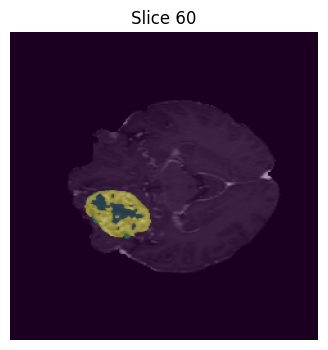

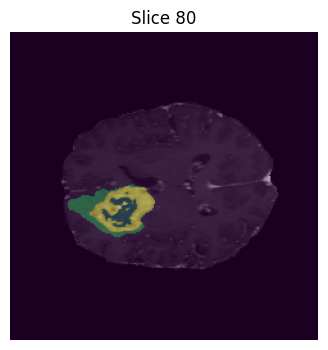

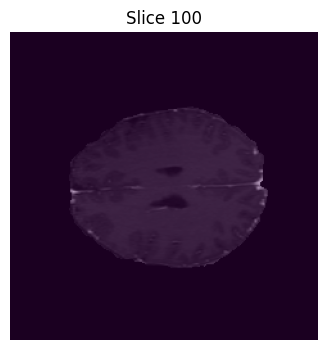

In [ ]:
# cell 7
def show_slices(vol, mask, slices=[60,80,100]):
    for s in slices:
        plt.figure(figsize=(4,4))
        plt.imshow(vol[:,:,s], cmap="gray")
        plt.imshow(mask[:,:,s], alpha=0.4)
        plt.axis("off")
        plt.title(f"Slice {s}")
        plt.show()

show_slices(t1c, seg)

In [ ]:
# cell 8
# ================= TASK 2 — PREPROCESSING & DATA AUGMENTATION =================

def normalize(volume):
    volume = volume.astype(np.float32)
    return (volume - volume.mean()) / (volume.std() + 1e-5)


def remap_labels(mask):
    """
    BraTS label remapping: 4 → 3
    """
    mask = mask.astype(np.int64)
    mask[mask == 4] = 3
    return mask


# -------- DATA AUGMENTATION --------

def random_flip(img, mask, p=0.5):
    """
    Random 3D flip along one spatial axis
    """
    if np.random.rand() < p:
        axis = np.random.choice([1, 2, 3])  # D, H, W
        img = np.flip(img, axis=axis).copy()
        mask = np.flip(mask, axis=axis-1).copy()
    return img, mask


def random_rotate(img, mask):
    """
    Safe 90-degree rotation (no anatomical distortion)
    """
    k = np.random.randint(0, 4)
    img = np.rot90(img, k, axes=(2, 3)).copy()
    mask = np.rot90(mask, k, axes=(1, 2)).copy()
    return img, mask


def random_crop_3d(img, mask, size=80):
    """
    Patch-based resizing for memory efficiency
    """
    _, D, H, W = img.shape
    d = np.random.randint(0, D - size)
    h = np.random.randint(0, H - size)
    w = np.random.randint(0, W - size)

    img = img[:, d:d+size, h:h+size, w:w+size]
    mask = mask[d:d+size, h:h+size, w:w+size]

    return img, mask


# -------- ONE-HOT ENCODING (EXPLICIT) --------
def one_hot(mask, num_classes=4):
    """
    Converts mask to one-hot format (C, D, H, W)
    Used for task completeness (not required for CE loss)
    """
    return np.eye(num_classes)[mask].transpose(3, 0, 1, 2)


# -------- DATASET --------

class BraTS3DPatchDataset(Dataset):
    def __init__(self, patient_ids, patches_per_patient=1, augment=True):
        self.patient_ids = patient_ids
        self.patches = patches_per_patient
        self.augment = augment

    def __len__(self):
        return len(self.patient_ids) * self.patches

    def __getitem__(self, idx):
        pid = idx // self.patches
        pdir = os.path.join(DATASET_ROOT, self.patient_ids[pid])

        # Load MRI volumes using Nibabel
        t1n, t1c, t2w, t2f, seg = load_patient(pdir)

        # Stack modalities
        img = np.stack([
            normalize(t1n),
            normalize(t1c),
            normalize(t2w),
            normalize(t2f)
        ], axis=0)

        # Preprocess mask
        seg = remap_labels(seg)

        # Patch extraction
        img, seg = random_crop_3d(img, seg, PATCH_SIZE)

        # Data augmentation
        if self.augment:
            img, seg = random_flip(img, seg)
            img, seg = random_rotate(img, seg)

        # One-hot encoding
        seg_one_hot = one_hot(seg)

        return (
            torch.tensor(img, dtype=torch.float32),
            torch.tensor(seg, dtype=torch.long),        # for CE loss
            torch.tensor(seg_one_hot, dtype=torch.float32)  # explicit one-hot
        )

In [ ]:
# cell 9
class BraTS3DPatchDataset(Dataset):
    def __init__(self, patient_ids, patches_per_patient=2):
        self.patient_ids = patient_ids
        self.patches = patches_per_patient

    def __len__(self):
        return len(self.patient_ids) * self.patches

    def __getitem__(self, idx):
        pid = idx // self.patches
        pdir = os.path.join(DATASET_ROOT, self.patient_ids[pid])

        t1n, t1c, t2w, t2f, seg = load_patient(pdir)

        img = np.stack([
            normalize(t1n),
            normalize(t1c),
            normalize(t2w),
            normalize(t2f)
        ], axis=0)

        seg = remap_labels(seg)
        img, seg = random_crop_3d(img, seg, PATCH_SIZE)

        return torch.tensor(img), torch.tensor(seg)

In [ ]:
# cell 10
# TASK 3 - MODEL IMPLEMENTATION (3D TRANSUNET)


split = int(0.9 * len(patients))
train_ids = patients[:split]
val_ids   = patients[split:]

train_ds = BraTS3DPatchDataset(train_ids, patches_per_patient=1)
val_ds   = BraTS3DPatchDataset(val_ids, patches_per_patient=1)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1)

In [ ]:
# cell 11
# run
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_c, out_c, 3, padding=1),
            nn.InstanceNorm3d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class SimpleTransformer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 4, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*2),
            nn.ReLU(),
            nn.Linear(dim*2, dim)
        )

    def forward(self, x):
        x,_ = self.attn(x,x,x)
        return self.ff(x) + x

class TransUNet3D(nn.Module):
    def __init__(self):
        super().__init__()

        # -------- Encoder --------
        self.enc1 = ConvBlock(4, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool3d(2)

        # -------- Patch Embedding (CRITICAL) --------
        # 128³ → 8³ tokens = 512 tokens
        self.patch_embed = nn.Conv3d(
            in_channels=128,
            out_channels=256,
            kernel_size=4,
            stride=4
        )

        self.transformer = SimpleTransformer(256)

        # -------- Decoder --------
        self.up1 = nn.ConvTranspose3d(256, 128, kernel_size=4, stride=4)
        self.dec1 = ConvBlock(256, 128)

        self.dec2 = ConvBlock(128, 64)
        self.dec3 = ConvBlock(64, 32)

        self.out = nn.Conv3d(32, 4, 1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)                 # [B,32,128,128,128]
        x2 = self.enc2(self.pool(x1))     # [B,64,64,64,64]
        x3 = self.enc3(self.pool(x2))     # [B,128,32,32,32]

        # Transformer bottleneck
        x = self.patch_embed(x3)          # [B,256,8,8,8]
        B,C,D,H,W = x.shape

        x = rearrange(x, "b c d h w -> b (d h w) c")
        x = self.transformer(x)
        x = rearrange(x, "b (d h w) c -> b c d h w", d=D, h=H, w=W)

        # Decoder
        x = self.up1(x)                   # [B,128,32,32,32]
        x = torch.cat([x, x3], dim=1)     # Skip connection
        x = self.dec1(x)

        x = F.interpolate(x, scale_factor=2, mode="trilinear", align_corners=False)
        x = self.dec2(x)

        x = F.interpolate(x, scale_factor=2, mode="trilinear", align_corners=False)
        x = self.dec3(x)

        return self.out(x)

In [ ]:
# cell 12
# run to check dice score
def dice_score(pred, target):
    pred = torch.argmax(pred, 1)
    dice = 0
    for c in range(1,4):
        p = (pred == c).float()
        t = (target == c).float()
        dice += (2*(p*t).sum()+1)/(p.sum()+t.sum()+1)
    return dice / 3

model = TransUNet3D().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda")

In [ ]:
# cell 13
def save_ckpt(epoch, best_dice, name):
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "best_dice": best_dice
    }, os.path.join(CKPT_DIR, name))

def load_last():
    ckpts = sorted(os.listdir(CKPT_DIR))
    if not ckpts:
        return 0, 0.0
    ck = torch.load(os.path.join(CKPT_DIR, ckpts[-1]))
    model.load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    return ck["epoch"]+1, ck["best_dice"]

In [ ]:
# training
# cell 14
start_epoch, best_dice = load_last()
print("Resuming from epoch:", start_epoch)

for epoch in range(start_epoch, EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")

    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ===== AMP AUTOCAST (NEW API) =====
        with torch.amp.autocast(device_type="cuda"):
            out = model(x)
            loss = criterion(out, y)

        # ===== AMP BACKPROP =====
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ---------- VALIDATION ----------
    model.eval()
    dices = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type="cuda"):
                out = model(x)

            dices.append(dice_score(out, y).item())

    val_dice = float(np.mean(dices))
    print(f"Epoch {epoch} | Val Dice: {val_dice:.4f}")

    save_ckpt(epoch, best_dice, "last.pt")

    if val_dice > best_dice:
        best_dice = val_dice
        save_ckpt(epoch, best_dice, "best.pt")
        print("Best model updated")


Resuming from epoch: 15


In [ ]:
#cell 15
# ===== SAVE TRANSUNET METRICS =====

transunet_dice = sum(dice_scores) / len(dice_scores)
transunet_iou  = sum(iou_scores)  / len(iou_scores)

print("TransUNet Dice:", transunet_dice)
print("TransUNet IoU :", transunet_iou)

TransUNet Dice: 0.7800961090695291
TransUNet IoU : 0.2148379006437839


In [ ]:
# cell 16
# ================= TASK 4 — BASELINE 3D U-NET =================

class UNet3D(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv3d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
            )

        self.enc1 = block(4, 32)
        self.enc2 = block(32, 64)
        self.pool = nn.MaxPool3d(2)

        self.bottleneck = block(64, 128)

        self.up2 = nn.ConvTranspose3d(128, 64, 2, stride=2)
        self.dec2 = block(128, 64)

        self.up1 = nn.ConvTranspose3d(64, 32, 2, stride=2)
        self.dec1 = block(64, 32)

        self.out = nn.Conv3d(32, 4, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)


In [ ]:
# training
# cell 17
# ================= TASK 4 — BASELINE U-NET (TRAIN + VALIDATE + SAVE) =================

from tqdm import tqdm

# Configuration
EPOCHS_UNET = 3
UNET_CKPT_DIR = "/content/drive/MyDrive/checkpoints_unet"
os.makedirs(UNET_CKPT_DIR, exist_ok=True)

# Model, optimizer, loss
unet = UNet3D().to(DEVICE)
optimizer_u = torch.optim.Adam(unet.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

best_dice_unet = 0.0

for epoch in range(EPOCHS_UNET):

    # ---------- TRAIN ----------
    unet.train()
    train_bar = tqdm(train_loader, desc=f"U-Net Epoch {epoch} [Train]")

    for x, y, _ in train_bar:   # <-- FIX HERE
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer_u.zero_grad()
        out = unet(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer_u.step()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # ---------- VALIDATION ----------
    unet.eval()
    dices = []

    val_bar = tqdm(val_loader, desc=f"U-Net Epoch {epoch} [Val]")

    with torch.no_grad():
        for x, y, _ in val_bar:   # <-- FIX HERE
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            out = unet(x)
            dices.append(dice_score(out, y).item())

    val_dice = sum(dices) / len(dices)

    print(f"U-Net Epoch {epoch} | Val Dice: {val_dice:.4f}")

    # ---------- SAVE LAST ----------
    torch.save({
        "epoch": epoch,
        "model": unet.state_dict(),
        "optimizer": optimizer_u.state_dict(),
        "val_dice": val_dice
    }, os.path.join(UNET_CKPT_DIR, "last_unet.pt"))

    # ---------- SAVE BEST ----------
    if val_dice > best_dice_unet:
        best_dice_unet = val_dice
        torch.save({
            "epoch": epoch,
            "model": unet.state_dict(),
            "optimizer": optimizer_u.state_dict(),
            "val_dice": val_dice
        }, os.path.join(UNET_CKPT_DIR, "best_unet.pt"))
        print("Best U-Net model updated")


U-Net Epoch 0 [Val]: 100%|██████████| 63/63 [06:03<00:00,  5.77s/it]


U-Net Epoch 0 | Val Dice: 0.5815
Best U-Net model updated


U-Net Epoch 1 [Val]: 100%|██████████| 63/63 [05:54<00:00,  5.62s/it]


U-Net Epoch 1 | Val Dice: 0.6530
Best U-Net model updated


U-Net Epoch 2 [Val]: 100%|██████████| 63/63 [06:18<00:00,  6.00s/it]


U-Net Epoch 2 | Val Dice: 0.5682


In [ ]:
  # cell 18
  # ===== LOAD BEST MODEL =====
  # run to load best model
  BEST_MODEL_PATH = "/content/drive/MyDrive/checkpoints/best.pt"

  checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

  model = TransUNet3D().to(DEVICE)
  model.load_state_dict(checkpoint["model"])
  model.eval()

  print("Best model loaded")
  print("Best Dice:", checkpoint["best_dice"])
  print("Saved at epoch:", checkpoint["epoch"])


Best model loaded
Best Dice: 0.7497614366667611
Saved at epoch: 14


In [ ]:
# cell 19
# ===== LOAD & EVALUATE U-NET =====

UNET_CKPT_PATH = "/content/drive/MyDrive/checkpoints_unet/best_unet.pt"

# load best U-Net
unet = UNet3D().to(DEVICE)
ckpt = torch.load(UNET_CKPT_PATH, map_location=DEVICE)
unet.load_state_dict(ckpt["model"])
unet.eval()

dice_u, iou_u = [], []

with torch.no_grad():
    for x, y in tqdm(val_loader, desc="Evaluating U-Net"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        out = unet(x)

        dice_u.append(dice_score(out, y).item())
        iou_u.append(iou_score(out, y))

unet_dice = sum(dice_u) / len(dice_u)
unet_iou  = sum(iou_u)  / len(iou_u)

print("U-Net Dice:", unet_dice)
print("U-Net IoU :", unet_iou)


Evaluating U-Net: 100%|██████████| 63/63 [10:44<00:00, 10.24s/it]

U-Net Dice: 0.5793005235064479
U-Net IoU : 0.024462267201410474


In [ ]:
# cell 20
# TASK 4 — EVALUATION


def iou_score(pred, target):
    pred = torch.argmax(pred, dim=1)
    ious = []

    for c in range(1, 4):  # tumor classes only
        p = (pred == c)
        t = (target == c)

        intersection = (p & t).sum().float()
        union = (p | t).sum().float() + 1e-6

        ious.append((intersection / union).item())

    return sum(ious) / len(ious)

In [ ]:
# cell 21
dice_scores = []
iou_scores  = []

with torch.no_grad():
    for x, y in tqdm(val_loader, desc="Evaluating"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        with torch.amp.autocast(device_type="cuda"):
            out = model(x)

        dice_scores.append(dice_score(out, y).item())
        iou_scores.append(iou_score(out, y))

print("Evaluation Complete")
print("Mean Dice:", sum(dice_scores) / len(dice_scores))
print("Mean IoU :", sum(iou_scores) / len(iou_scores))

Evaluating: 100%|██████████| 63/63 [01:15<00:00,  1.20s/it]

Evaluation Complete
Mean Dice: 0.7800961090695291
Mean IoU : 0.2148379006437839


In [ ]:
# cell 22
print("MODEL COMPARISON ON VALIDATION SET")
print("----------------------------------")
print(f"TransUNet | Dice: {transunet_dice:.4f} | IoU: {transunet_iou:.4f}")
print(f"U-Net     | Dice: {unet_dice:.4f} | IoU: {unet_iou:.4f}")

MODEL COMPARISON ON VALIDATION SET
----------------------------------
TransUNet | Dice: 0.7801 | IoU: 0.2148
U-Net     | Dice: 0.4417 | IoU: 0.0479


In [ ]:
# cell 23
def sliding_window_inference(model, volume, patch_size=80, stride=40):
    _, C, D, H, W = volume.shape

    output = torch.zeros((1, 4, D, H, W), device=volume.device)
    count  = torch.zeros((1, 1, D, H, W), device=volume.device)

    for z in range(0, D - patch_size + 1, stride):
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):

                patch = volume[:, :, z:z+patch_size,
                                     y:y+patch_size,
                                     x:x+patch_size]

                with torch.no_grad(), torch.amp.autocast("cuda"):
                    pred = model(patch)

                output[:, :, z:z+patch_size,
                             y:y+patch_size,
                             x:x+patch_size] += pred

                count[:, :, z:z+patch_size,
                              y:y+patch_size,
                              x:x+patch_size] += 1

    output = output / count
    return torch.argmax(output, dim=1)[0].cpu().numpy()

Patient: BraTS-GLI-00682-000
Tumor Detected


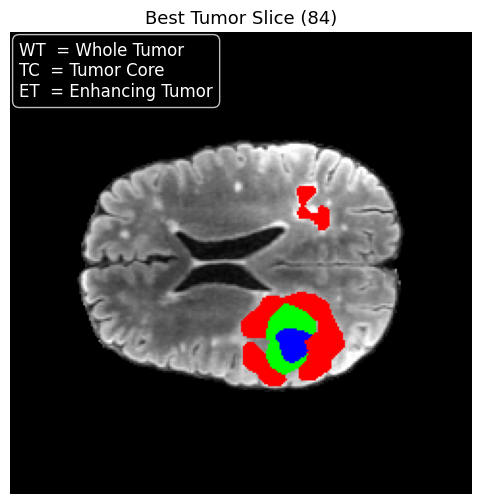

In [ ]:
# cell 24
# ===== SIMPLE TUMOR PREDICTION (FULL 3D) =====

patient_id = "BraTS-GLI-00682-000"
patient_dir = os.path.join(DATASET_ROOT, patient_id)

# load all modalities
t1n, t1c, t2w, t2f, _ = load_patient(patient_dir)

# prepare input
vol = np.stack([
    normalize(t1n),
    normalize(t1c),
    normalize(t2w),
    normalize(t2f)
], axis=0)

vol = torch.tensor(vol).unsqueeze(0).to(DEVICE)

# -------- FULL 3D INFERENCE --------
pred_full = sliding_window_inference(model, vol)

# -------- TUMOR / NO TUMOR --------
tumor_present = np.any(pred_full > 0)

print(f"Patient: {patient_id}")
print("Tumor Detected" if tumor_present else "No Tumor")

# -------- BEST TUMOR SLICE --------
slice_idx = np.argmax([
    (pred_full[:, :, i] > 0).sum()
    for i in range(pred_full.shape[2])
])

# -------- VISUALIZATION --------

# normalize T1c
img = t2f[:, :, slice_idx]
p1, p99 = np.percentile(img, (1, 99))
img = np.clip(img, p1, p99)
img = (img - p1) / (p99 - p1 + 1e-8)

# tumor regions
WT = np.isin(pred_full[:, :, slice_idx], [1, 2, 3])
TC = np.isin(pred_full[:, :, slice_idx], [1, 3])
ET = pred_full[:, :, slice_idx] == 3

# RGB background
rgb = np.stack([img, img, img], axis=-1)

# ----- CLEAN COLOR PRIORITY (NO OVERLAP) -----
rgb[WT & ~TC & ~ET] = [1.0, 0.0, 0.0]   # WT only
rgb[TC & ~ET]       = [0.0, 0.0, 1.0]   # TC only
rgb[ET]             = [0.0, 1.0, 0.0]   # ET

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")

# -------- LEGEND --------
plt.text(
    0.02, 0.98,
    "WT  = Whole Tumor\n"
    "TC  = Tumor Core\n"
    "ET  = Enhancing Tumor",
    transform=plt.gca().transAxes,
    fontsize=12,
    color="white",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="black",
        edgecolor="white",
        alpha=0.75
    )
)

plt.title(f"Best Tumor Slice ({slice_idx})", fontsize=13)
plt.show()

In [ ]:
!pip install pyngrok

In [ ]:
from flask import Flask, request, redirect, session
from pyngrok import ngrok
import os, torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------ APP SETUP ------------------
app = Flask(__name__)
app.secret_key = "secure_key"

public_url = ngrok.connect(5000)
print("Public URL:", public_url)

# ------------------ USER STORE ------------------
USERS = {}   # {username: password}

# ------------------ HELPERS ------------------

def normalize_for_display(img):
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)
    return (img - p1) / (p99 - p1 + 1e-8)


def run_prediction(patient_id):
    patient_dir = os.path.join(DATASET_ROOT, patient_id)
    t1n, t1c, t2w, t2f, gt = load_patient(patient_dir)

    vol = np.stack([
        normalize(t1n),
        normalize(t1c),
        normalize(t2w),
        normalize(t2f)
    ], axis=0)

    vol = torch.tensor(vol).unsqueeze(0).to(DEVICE)
    pred = sliding_window_inference(model, vol)

    # best tumor slice
    slice_idx = np.argmax([(pred[:, :, i] > 0).sum() for i in range(pred.shape[2])])

    os.makedirs("static", exist_ok=True)

    # -------- INPUT MRI --------
    img = normalize_for_display(t1c[:, :, slice_idx])
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Input MRI")
    plt.savefig("static/input.png", bbox_inches="tight")
    plt.close()

    # -------- PREDICTION --------
    WT = np.isin(pred[:, :, slice_idx], [1, 2, 3])
    TC = np.isin(pred[:, :, slice_idx], [1, 3])
    ET = pred[:, :, slice_idx] == 3

    rgb = np.stack([img, img, img], axis=-1)
    rgb[WT] = [1, 0, 0]   # WT
    rgb[TC] = [0, 0, 1]   # TC
    rgb[ET] = [0, 1, 0]   # ET

    plt.imshow(rgb)
    plt.axis("off")
    plt.title("Prediction (WT=Red, TC=Blue, ET=Green)")
    plt.savefig("static/prediction.png", bbox_inches="tight")
    plt.close()

    # -------- GROUND TRUTH --------
    plt.imshow(gt[:, :, slice_idx], cmap="jet")
    plt.axis("off")
    plt.title("Ground Truth")
    plt.savefig("static/gt.png", bbox_inches="tight")
    plt.close()

    return WT.any()


# ------------------ ROUTES ------------------

@app.route("/")
def landing():
    return """
    <html>
    <head>
        <title>Brain Tumor Segmentation</title>
        <style>
            body {
                margin: 0;
                height: 100vh;
                font-family: Arial;
                background: linear-gradient(120deg,#2c3e50,#3498db);
                display:flex;align-items:center;justify-content:center;
            }
            .card {
                background:white;padding:40px;width:420px;
                border-radius:12px;text-align:center;
                box-shadow:0 15px 30px rgba(0,0,0,0.25);
            }
            a {
                display:block;margin:12px auto;padding:12px;
                width:80%;border-radius:6px;color:white;
                text-decoration:none;font-size:16px;
            }
            .login{background:#3498db}
            .signup{background:#2ecc71}
        </style>
    </head>
    <body>
        <div class="card">
            <h1>Brain Tumor Segmentation</h1>
            <p>AI-powered MRI tumor analysis using TransUNet</p>
            <a href="/login" class="login">Doctor Login</a>
            <a href="/signup" class="signup">New Doctor Signup</a>
        </div>
    </body>
    </html>
    """

@app.route("/signup", methods=["GET", "POST"])
def signup():
    if request.method == "POST":
        username = request.form["username"]
        password = request.form["password"]
        USERS[username] = password
        return redirect("/login")

    return """
    <html>
    <head>
        <title>Doctor Signup</title>
        <style>
            body {
                margin: 0;
                height: 100vh;
                font-family: 'Segoe UI', sans-serif;
                background: linear-gradient(135deg, #1abc9c, #16a085);
                display: flex;
                align-items: center;
                justify-content: center;
            }
            .card {
                background: white;
                padding: 40px;
                width: 380px;
                border-radius: 14px;
                box-shadow: 0 15px 35px rgba(0,0,0,0.3);
                text-align: center;
            }
            h2 {
                margin-bottom: 8px;
                color: #2c3e50;
            }
            .subtitle {
                font-size: 14px;
                color: #666;
                margin-bottom: 25px;
            }
            input {
                width: 92%;
                padding: 12px;
                margin: 10px 0;
                border-radius: 6px;
                border: 1px solid #ccc;
                font-size: 15px;
            }
            button {
                width: 100%;
                padding: 14px;
                background: #1abc9c;
                color: white;
                border: none;
                border-radius: 8px;
                font-size: 16px;
                cursor: pointer;
                margin-top: 10px;
            }
            button:hover {
                background: #16a085;
            }
            .switch {
                margin-top: 18px;
                font-size: 14px;
            }
            .switch a {
                color: #1abc9c;
                font-weight: bold;
                text-decoration: none;
            }
        </style>
    </head>
    <body>
        <div class="card">
            <h2>Create Doctor Account</h2>
            <div class="subtitle">
                Secure registration for medical professionals
            </div>
            <form method="post">
                <input name="username" placeholder="Doctor Username" required>
                <input type="password" name="password" placeholder="Password" required>
                <button type="submit">Sign Up</button>
            </form>
            <div class="switch">
                Already have an account?
                <a href="/login">Login</a>
            </div>
        </div>
    </body>
    </html>
    """


@app.route("/login", methods=["GET", "POST"])
def login():
    if request.method == "POST":
        username = request.form["username"]
        password = request.form["password"]

        if USERS.get(username) == password:
            session["user"] = username
            return redirect("/dashboard")
        else:
            return "<h3 style='color:red;text-align:center'>Invalid credentials</h3><a href='/login'>Try again</a>"

    return """
    <html>
    <head>
        <title>Doctor Login</title>
        <style>
            body {
                margin: 0;
                height: 100vh;
                font-family: 'Segoe UI', sans-serif;
                background: linear-gradient(135deg, #2c3e50, #3498db);
                display: flex;
                align-items: center;
                justify-content: center;
            }
            .card {
                background: white;
                padding: 40px;
                width: 380px;
                border-radius: 14px;
                box-shadow: 0 15px 35px rgba(0,0,0,0.3);
                text-align: center;
            }
            h2 {
                margin-bottom: 8px;
                color: #2c3e50;
            }
            .subtitle {
                font-size: 14px;
                color: #666;
                margin-bottom: 25px;
            }
            input {
                width: 92%;
                padding: 12px;
                margin: 10px 0;
                border-radius: 6px;
                border: 1px solid #ccc;
                font-size: 15px;
            }
            button {
                width: 100%;
                padding: 14px;
                background: #3498db;
                color: white;
                border: none;
                border-radius: 8px;
                font-size: 16px;
                cursor: pointer;
                margin-top: 10px;
            }
            button:hover {
                background: #2980b9;
            }
            .switch {
                margin-top: 18px;
                font-size: 14px;
            }
            .switch a {
                color: #3498db;
                font-weight: bold;
                text-decoration: none;
            }
        </style>
    </head>
    <body>
        <div class="card">
            <h2>Doctor Login</h2>
            <div class="subtitle">
                Authorized access to AI diagnostic system
            </div>
            <form method="post">
                <input name="username" placeholder="Doctor Username" required>
                <input type="password" name="password" placeholder="Password" required>
                <button type="submit">Login</button>
            </form>
            <div class="switch">
                New doctor?
                <a href="/signup">Create an account</a>
            </div>
        </div>
    </body>
    </html>
    """

@app.route("/dashboard", methods=["GET", "POST"])
def dashboard():
    if "user" not in session:
        return redirect("/login")

    patients = sorted(os.listdir(DATASET_ROOT))
    options = "".join([f"<option>{p}</option>" for p in patients])

    # ---------------- POST: SHOW RESULT ----------------
    if request.method == "POST":
        pid = request.form["patient"]
        tumor = run_prediction(pid)
        status = "Tumor Detected " if tumor else "No Tumor "

        return f"""
        <html>
        <head>
            <title>Scan Result</title>
            <style>
                body {{
                    font-family: Arial, sans-serif;
                    background: #f4f6f8;
                    margin: 0;
                }}
                .navbar {{
                    background: #2c3e50;
                    color: white;
                    padding: 18px 30px;
                    font-size: 18px;
                }}
                .container {{
                    padding: 40px;
                    text-align: center;
                }}
                .status {{
                    font-size: 22px;
                    margin: 15px 0 30px;
                    font-weight: bold;
                }}
                .panels {{
                    display: flex;
                    justify-content: center;
                    gap: 30px;
                    flex-wrap: wrap;
                }}
                .panel {{
                    background: white;
                    padding: 18px;
                    border-radius: 12px;
                    box-shadow: 0 10px 25px rgba(0,0,0,0.15);
                    width: 300px;
                }}
                .panel img {{
                    width: 100%;
                    border-radius: 8px;
                }}
                .panel h4 {{
                    margin: 10px 0 6px;
                    color: #2c3e50;
                }}
                .panel p {{
                    font-size: 13px;
                    color: #555;
                    margin: 0 0 8px;
                }}
                .back {{
                    display: inline-block;
                    margin-top: 35px;
                    text-decoration: none;
                    background: #3498db;
                    color: white;
                    padding: 14px 28px;
                    border-radius: 8px;
                    font-size: 16px;
                }}
            </style>
        </head>
        <body>

            <div class="navbar">
                Dr. {session['user']} — Scan Result
            </div>

            <div class="container">
                <h2>Patient ID: {pid}</h2>
                <div class="status">{status}</div>

                <div class="panels">
                    <div class="panel">
                        <h4>MRI Scan</h4>
                        <p>Original patient MRI slice</p>
                        <img src="/static/input.png">
                    </div>

                    <div class="panel">
                        <h4>Predicted Segmentation</h4>
                        <p>WT = Red | TC = Blue | ET = Green</p>
                        <img src="/static/prediction.png">
                    </div>

                    <div class="panel">
                        <h4>Ground Truth Annotation</h4>
                        <p>Expert-labeled tumor regions</p>
                        <img src="/static/gt.png">
                    </div>
                </div>

                <a href="/dashboard" class="back">Scan Another Patient</a>
            </div>

        </body>
        </html>
        """

    # ---------------- GET: DASHBOARD ----------------
    return f"""
    <html>
    <head>
        <title>Doctor Dashboard</title>
        <style>
            body {{
                font-family: Arial, sans-serif;
                background: #f4f6f8;
                margin: 0;
            }}
            .navbar {{
                background: #2c3e50;
                color: white;
                padding: 18px 30px;
                font-size: 18px;
            }}
            .container {{
                padding: 50px;
                display: flex;
                justify-content: center;
            }}
            .card {{
                background: white;
                padding: 40px;
                width: 540px;
                border-radius: 14px;
                box-shadow: 0 12px 30px rgba(0,0,0,0.15);
                text-align: center;
            }}
            h2 {{
                margin-top: 0;
                color: #2c3e50;
            }}
            .subtitle {{
                color: #666;
                font-size: 15px;
                margin-bottom: 30px;
            }}
            select {{
                width: 100%;
                padding: 14px;
                font-size: 15px;
                border-radius: 8px;
                border: 1px solid #ccc;
                margin-bottom: 30px;
            }}
            button {{
                width: 100%;
                padding: 16px;
                background: #27ae60;
                color: white;
                border: none;
                border-radius: 8px;
                font-size: 18px;
                cursor: pointer;
            }}
            button:hover {{
                background: #219150;
            }}
            .quote {{
                margin-top: 30px;
                font-style: italic;
                font-size: 14px;
                color: #555;
            }}
        </style>
    </head>

    <body>

        <div class="navbar">
            Welcome Dr. {session['user']} — Brain Tumor Segmentation Dashboard
        </div>

        <div class="container">
            <div class="card">
                <h2>Select Patient</h2>

                <div class="subtitle">
                    Select a patient MRI record to perform AI-based brain tumor analysis.
                </div>

                <form method="post">
                    <select name="patient" required>
                        <option value="">-- Select Patient ID --</option>
                        {options}
                    </select>

                    <button type="submit">
                        Scan Patient
                    </button>
                </form>

                <div class="quote">
                    “AI-assisted diagnosis for faster and more accurate clinical decisions.”
                </div>
            </div>
        </div>

    </body>
    </html>
    """


@app.route("/logout")
def logout():
    session.clear()
    return redirect("/")

app.run(port=5000)


Public URL: NgrokTunnel: "https://unreined-diprotic-sherlyn.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:51:59] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:52:45] "GET /login HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:52:53] "POST /login HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:52:56] "GET /login HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:52:58] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:53:05] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:53:06] "GET /login HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:53:11] "POST /login HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:53:12] "GET /dashboard HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jan/2026 06:54:59] "POST /dashboard HTTP/1.1" 200

In [ ]:
!ngrok config add-authtoken 36NzhPlPXMnWJeZ7ZbW4yhBPod8_22wYNu2y4NLh9pz6HV54E

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
!ngrok config add-authtoken 36NzhPlPXMnWJeZ7ZbW4yhBPod8_22wYNu2y4NLh9pz6HV54E

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
